<밑바닥부터 시작하는 딥러닝, 사이토 고키, 한빛미디어> => 현재 이 책 위주로 딥러닝 수업

https://karpathy.github.io/neuralnets/

https://cs231n.github.io/ => 강의 추천

위 두 링크는 '밑바닥부터 시작하는 딥러닝' 저자가 참고한 내용들

<기계학습, 오일석, 한빛아카데미> => 표현법이 다름 조금 시간 들여서 공부해야 함

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [102]:
from scipy.special import expit
import pickle
from drive.MyDrive.data.mnistdata.mnist import load_mnist

# 오차역전파

계산 그래프 : 계산과정을 그래프로 나타낸것
```
노드와 엣지로 표현
노드에는 연산자, 엣지에는 값을 사용
```

계산 그래프 사용
```
1. 계산그래프를 그린다.
2. 그래프에서 계산을 왼쪽에서 오른쪽으로 수행한다. (순전파)
```

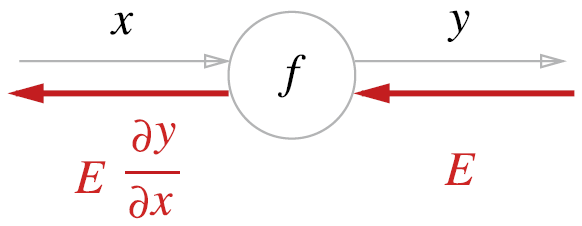

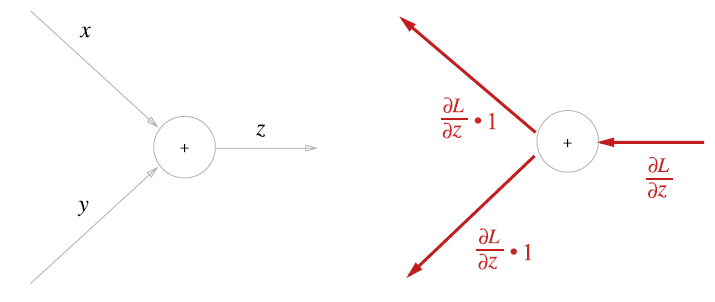

In [103]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

In [104]:
def sigmoid(x):
    return expit(x)

def sigmoid_grad(x):
    return (1.0 - sigmoid(x)) * sigmoid(x)

def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T
    x = x - np.max(x)
    return np.exp(x) / np.sum(np.exp(x))

def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    if t.size == y.size:
        t = t.argmax(axis=1)
    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size

def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)
        x[idx] = tmp_val - h
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val
        it.iternext()
    return grad

In [105]:
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01): # 가중치를 weight_init_std 표준편차로 주겠다.
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        return y

    def loss(self, x, t):
        y = self.predict(x)
        return cross_entropy_error(y, t)

    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        return grads

    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]

        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        #backward
        dy = (y-t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)

        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)
        return grads

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        accuracy_ = np.sum(y == t) / float(x.shape[0])
        return accuracy_

In [106]:
nwt_grads = TwoLayerNet(784, 50, 10)
x_batch = x_train[:4]
t_batch = t_train[:4]

In [107]:
grad_numerical = nwt_grads.numerical_gradient(x_batch, t_batch)
grad_back = nwt_grads.gradient(x_batch, t_batch)

In [108]:
for key in grad_numerical.keys():
    diff = np.average(np.abs(grad_back[key] - grad_numerical[key]))
    print(diff)

3.786457768381884e-13
1.1777980001882738e-12
1.491251820640027e-11
1.201261354277783e-10


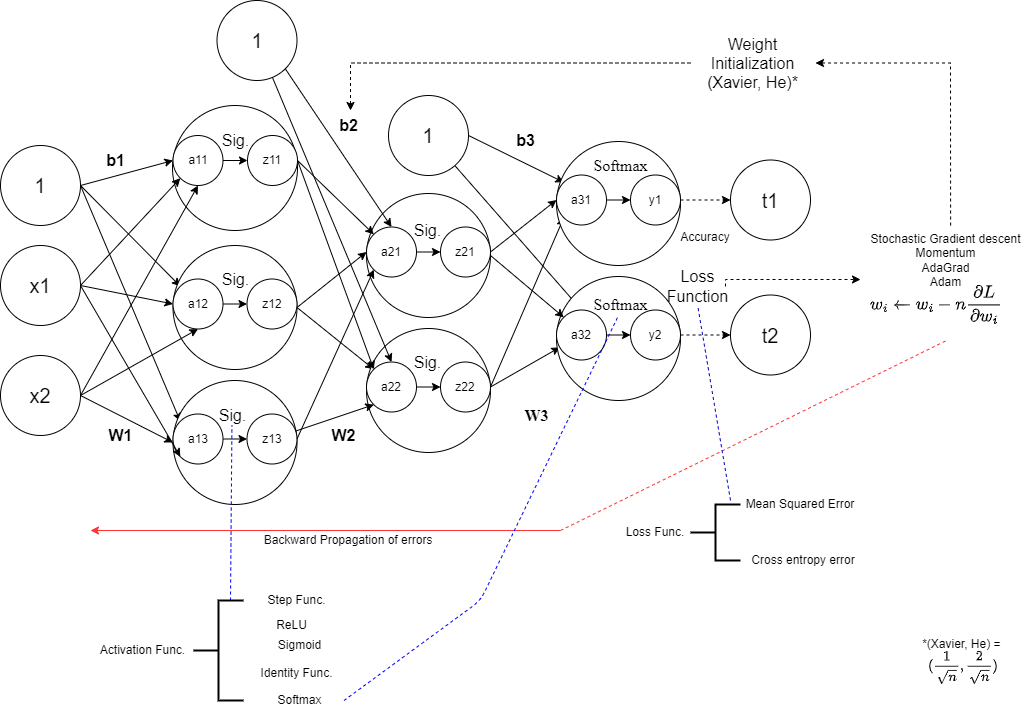

사과 3개 살 경우
```
100 * 3 * 1.1 = 330
3 * 110 = 330
```

사과 가격이 101로 올랐을 때
```
101 * 2.2 = 222.222...
```
이걸 식으로 나타냈을 때

$y = ax$<br>
a : 기울기

사과의 단가가 1 만큼 변했을 때  --> 총 가격은 2.2 만큼 변했다. --> $\partial  가격\over \partial 단가$ = 2.2 --> 기울기

매개변수 $w_i$가 1만큼 변했을 때 --> 손실함수 $L$은 2.2 만큼 변했다. --> $\partial L \over \partial w_i$ = 2.2 --> 기울기

# 곱셈에 대하여

$y = ax$ $\therefore \frac{\partial y}{\partial x}$

$$ z = x y
$$
\begin{equation*}
\frac{\partial z}{\partial x} = y
\end{equation*}
\begin{equation*}
\frac{\partial z}{\partial y} = x
\end{equation*}

# ReLU 역전파

\begin{equation*}
y = x ( x > 0 )
\end{equation*}
\begin{equation*}
y = 0 ( x <= 0 )
\end{equation*}
#### 위 식을 x에 대하여 각각 미분 하면
\begin{equation*}
\frac{\partial y}{\partial x} = 1 ( x > 0 )
\end{equation*}
\begin{equation*}
\frac{\partial y}{\partial x} = 0 ( x <= 0 )
\end{equation*}

In [109]:
class Relu:
    def __init__(self):
        self.mask = None

    # 순전파
    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0
        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout
        return dx

In [110]:
x = np.array([[1.0, 0.5], [-2.0, 3.0]])
x

array([[ 1. ,  0.5],
       [-2. ,  3. ]])

In [111]:
mask = (x <= 0)
mask

array([[False, False],
       [ True, False]])

In [112]:
out = x.copy()
out[mask] = 0
out

array([[1. , 0.5],
       [0. , 3. ]])

# Sigmoid

$$
\begin{equation*}
y = \frac{1}{1 + exp(-x)}
\end{equation*}
$$
<br>
<br>
\begin{equation*}
y = {1 \over x}\\
\frac{\partial y}{\partial x} = -\frac{1}{x^{2}}
\end{equation*}
\begin{equation*}
= - y^{2}
\end{equation*}

In [113]:
class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out
        return dx

# Affine 변환<br>
: 신경망의 순전파에서 가중치 신호의 총 합을 계산하기 위해 수행하는 행렬곱

In [114]:
X = np.random.randn(2)
W = np.random.randn(2, 3)
B = np.random.randn(3)

In [115]:
X.shape, W.shape, B.shape

((2,), (2, 3), (3,))

$$
\frac{\partial L}{\partial W} = \frac{\partial L}{\partial Y} \frac{\partial Y}{\partial W}
$$

\begin{equation*}
\frac{\partial L}{\partial X}(N,2) = \frac{\partial L}{\partial Y}(N,3) W^{T} (3,2)
\end{equation*}
\begin{equation*}
\frac{\partial L}{\partial W}(2,3) = X^{T}(2,N) \frac{\partial L}{\partial Y} (N,3)
\end{equation*}
\begin{equation*}
\frac{\partial L}{\partial B}(3) = \frac{\partial L}{\partial Y} (N,3)의 첫번째 축 (axis = 0)의 합
\end{equation*}


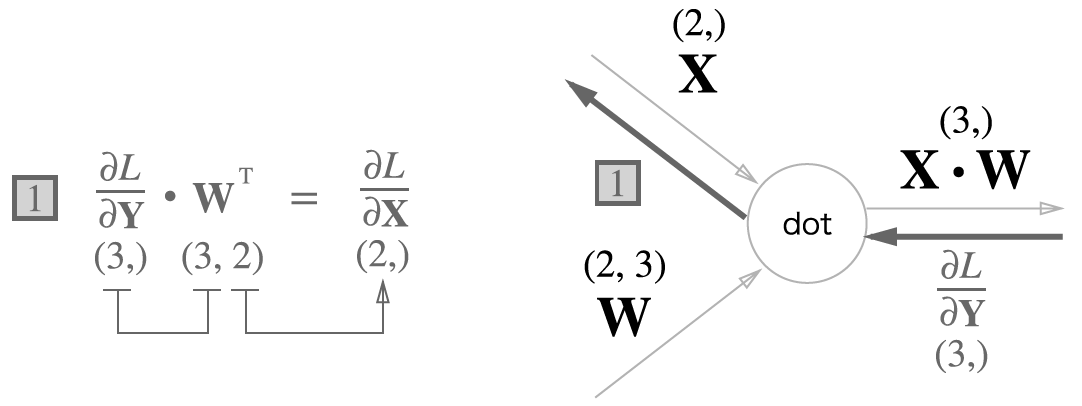

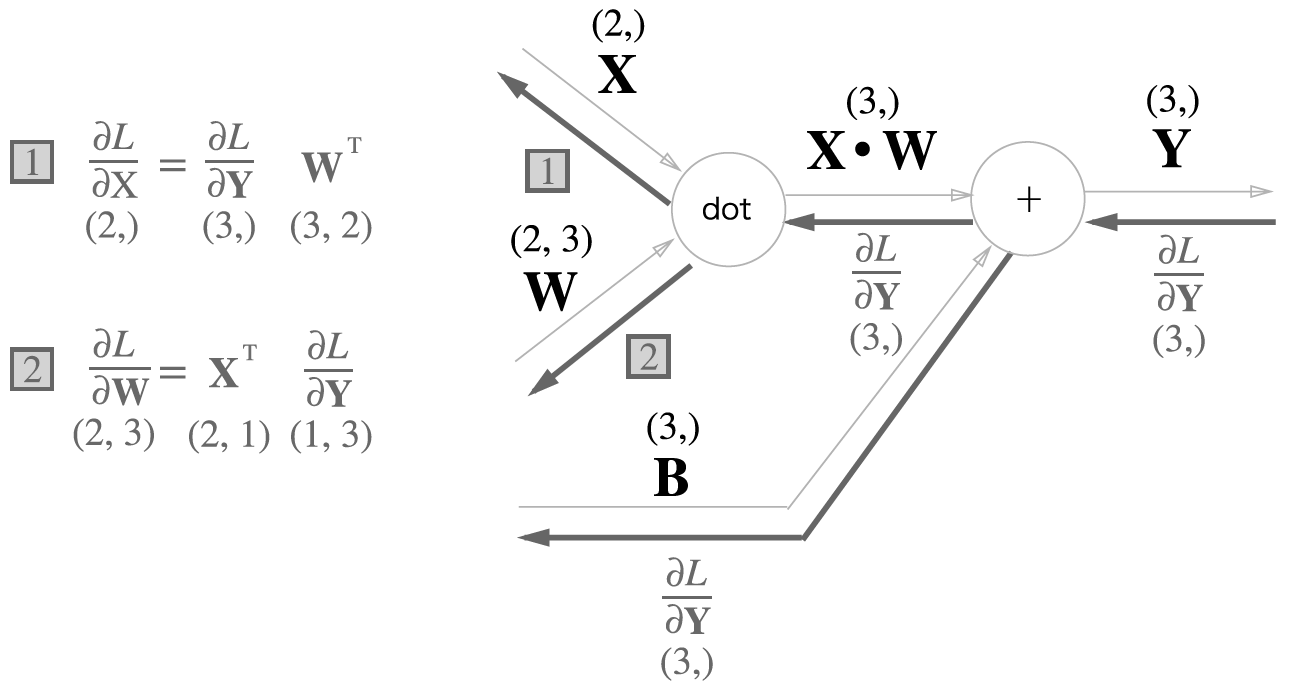

In [116]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b
        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        out = np.dot(x, self.W) + self.b
        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)
        return dx

# Softmax - with - Loss

Softmax 함수와 교차 엔트로피 오차를 함께 계산하여 오차역전파를 계산함

$$E = - \sum\limits_{k} t_k logy_k$$

In [117]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)
        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        dx = (self.y - self.t) / batch_size
        return dx

정답 (0, 1, 0), 소프트맥스 계층 (0.3, 0.2, 0.5) ---> 역전파 (0.3, -0.8, 0.5)

정답 (0, 1, 0), 소프트맥스 계층(0.01, 0.99, 0) ---> 역전파 (0.01, -0.01, 0)

In [118]:
from collections import OrderedDict
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)
        #계층 생성
        self.layers = OrderedDict()
        self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
        self.layers['Relu1'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])
        self.lastLayer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        return x

    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)
        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        return grads

    def gradient(self, x, t):
        # forward
        self.loss(x, t)
        # backward
        dout = 1
        dout = self.lastLayer.backward(dout)
        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)
        #기울기 저장
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W2'], grads['b2'] = self.layers['Affine2'].dW, self.layers['Affine2'].db
        return grads

In [119]:
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iter_num = 10000
train_size = x_train.shape[0]
learning_rate = 0.1
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size // batch_size, 1) # 한 레포크당 반복 횟수

for i in range(iter_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # grad = network.numerical_gradient(x_batch, t_batch) # 784번 해야해서 엄청 기다려야함 4시간 정도 예상
    grad = network.gradient(x_batch, t_batch) # 4시간 돌리긴 힘드니 shape 단축, 검사용

    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(f'train acc : {train_acc}')
        print(f'test acc : {test_acc}')

train acc : 0.12595
test acc : 0.1289
train acc : 0.9022
test acc : 0.9063
train acc : 0.9233166666666667
test acc : 0.9255
train acc : 0.9356333333333333
test acc : 0.9358
train acc : 0.9456
test acc : 0.9431
train acc : 0.9538333333333333
test acc : 0.9506
train acc : 0.9590166666666666
test acc : 0.9543
train acc : 0.9610666666666666
test acc : 0.9551
train acc : 0.9647833333333333
test acc : 0.9579
train acc : 0.9694666666666667
test acc : 0.9639
train acc : 0.9713666666666667
test acc : 0.9656
train acc : 0.9718666666666667
test acc : 0.9656
train acc : 0.9747166666666667
test acc : 0.968
train acc : 0.9758666666666667
test acc : 0.9678
train acc : 0.9777333333333333
test acc : 0.9692
train acc : 0.9794833333333334
test acc : 0.9714
train acc : 0.9790833333333333
test acc : 0.9698


# Optimizer

1. SGD (확률절 경사하강법)
    : 무작위로 골라낸 데이터에 대해 수행하는 경하 하강법

    : 미니배치를 사용해 무작위로 선택한 데이터 사용

2. momentum
    : 국소 죄소점을 벗어 날 수 있도록 SGD에 가중치의 1차식을 더해준 방식

3. Adagrad
    : 고정된 학습률이 아닌 변화하는 학습률을 적용

4. Rmsprop
     : Adagrad에서 학습률이 줄어드는 문제를 해결한 옵티마이저

5. Adam : momentum + AdaGrad

최적화 : 손실 함수의 값을 가능한 낮추는 매개변수를 찾는 과정

# SGD

\begin{equation*}
W \leftarrow W - \eta \frac{\partial L}{\partial W}
\end{equation*}
\begin{equation*}
W : 갱신할, 매개변수
\end{equation*}
\begin{equation*}
\frac{\partial L}{\partial W} : 손실 함수의 기울기
\end{equation*}
\begin{equation*}
\eta : 학습률, 미리 정해서 사용
\end{equation*}

In [120]:
from drive.MyDrive.data import optimizer, layers, gradient, functions
from drive.MyDrive.data.multi_layer_net import MultiLayerNet
from drive.MyDrive.data.util import smooth_curve

In [121]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    def update (self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

# Momentum (운동량)

\begin{equation*}
v_n \leftarrow \alpha v - \eta \frac{\partial{L}}{\partial{W}}
\end{equation*}
\begin{equation*}
W \leftarrow W + v
\end{equation*}
\begin{equation*}
W : 갱신할 .매개변수
\end{equation*}
\begin{equation*}
\frac{\partial L}{\partial W} : 손실 함수의 기울기
\end{equation*}
\begin{equation*}
\eta : 학습률, 미리 정해서 사용
\end{equation*}


$$
w = w - \eta\frac{\partial L}{\partial W} + \alpha v
$$

즉, 기울기를 더해서 구덩이에서 빠져 나오게 한다.

In [122]:
class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)
        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
            params[key] += self.v[key]

# AdaGrad

학습률 감소(learning rate decay) : 학습을 진행하면서 학습률을 점차 줄여가는 방법
개별 매개변수에 적응적으로(adative) 학습률을 조정하면서 학습을 진행
\begin{equation*}
h \leftarrow h + \frac{\partial{L}}{\partial{W}} \odot \frac{\partial{L}}{\partial{W}}
\end{equation*}
\begin{equation*}
W \leftarrow W - \eta \frac{1}{\sqrt{h}} \frac{\partial{L}}{\partial{W}}
\end{equation*}
\begin{equation*}
W : 갱신할, 매개변수
\end{equation*}
\begin{equation*}
\frac{\partial L}{\partial W} : 손실 함수의 기울기
\end{equation*}
\begin{equation*}
\eta : 학습률, 미리 정해서 사용
\end{equation*}

h : 기존 기울기 값을 제곱하여 계속 더해줌

Hadamard 곱 : 각 행렬 원소들 끼리의 곱

# Rmsprop

In [123]:
class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None
    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key] + 1e-7))

# Adam
: Momentum 과 Adagrad 기법을 융합

: 하이퍼파라미터의 "편향 보정"이 진행됨

In [124]:
class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)

        self.iter += 1 # iter = iter + 1 --> n = n + 1
        lr_t = self.lr * np.sqrt(1.0 - self.beta2 ** self.iter) / (1.0 - self.beta1 ** self.iter)
        for key in params.keys():
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            # m = m + (1 - beta1) * (grads - m)
            # m = m + (1 - beta1) * (-m) + (1 - beta1) * (grads)
            self.v[key] += (1 - self.beta2) * (grads[key] ** 2 - self.v[key])
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key] + 1e-7))

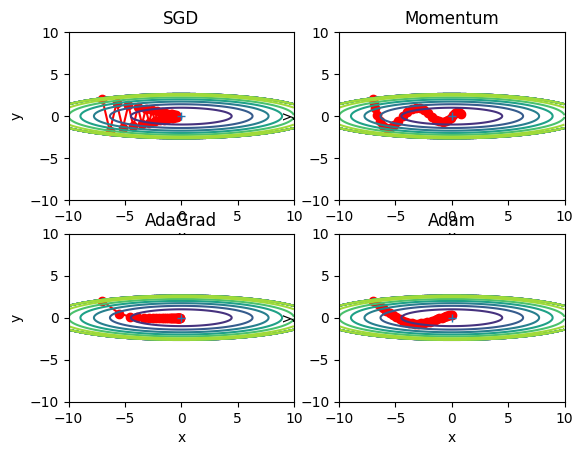

In [125]:
def f(x, y):
    return x**2 / 20.0 + y**2
def df(x, y):
    return x / 10.0, 2.0*y
init_pos = (-7.0, 2.0)
params = {}
grads = {}
grads['x'], grads['y'] = 0, 0
optimizers = OrderedDict()
optimizers['SGD'] = SGD(lr=0.95)
optimizers['Momentum'] = Momentum(lr = 0.1)
optimizers['AdaGrad'] = AdaGrad(lr = 1.5)
optimizers['Adam'] = Adam(lr = 0.3)

idx = 1
for key in optimizers:
    optimizer = optimizers[key]
    x_history=[]
    y_history=[]
    params['x'], params['y'] = init_pos[0], init_pos[1]
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    # 외곽선 단순화
    mask = Z > 7
    Z[mask] = 0
    # 그래프 그리기
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")

===============iteration : 0==========
SGD  ::  2.3262236270161423
Momentum  ::  2.3750366170426664
AdaGrad  ::  2.362578855803328
Adam  ::  2.289672151964666
===============iteration : 100==========
SGD  ::  1.731265932971541
Momentum  ::  0.3000753314465637
AdaGrad  ::  0.13000453473152285
Adam  ::  0.2231479174833672
===============iteration : 200==========
SGD  ::  1.0255441785541144
Momentum  ::  0.2552660772946489
AdaGrad  ::  0.07844042461824886
Adam  ::  0.22162438519237912
===============iteration : 300==========
SGD  ::  0.7500595155018284
Momentum  ::  0.36519428455866787
AdaGrad  ::  0.19861409287662238
Adam  ::  0.2579456781275593
===============iteration : 400==========
SGD  ::  0.32699095176696746
Momentum  ::  0.09595010783849739
AdaGrad  ::  0.037447958874012935
Adam  ::  0.09221234242109214
===============iteration : 500==========
SGD  ::  0.3952980750355765
Momentum  ::  0.22521027657493614
AdaGrad  ::  0.08196067364608495
Adam  ::  0.1541975862473759
===============

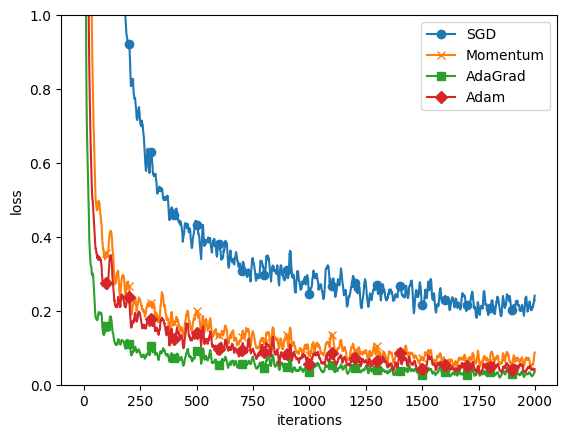

In [126]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000

optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
networks = {}
train_loss = {}

for key in optimizers.keys():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10)
    train_loss[key] = []
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    if i % 100 == 0 :
        print('==============='+'iteration : '+str(i) + '==========')
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + '  ::  ' + str(loss))

markers = {'SGD':'o', 'Momentum':'x', 'AdaGrad':'s', 'Adam':'D'}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key )
plt.xlabel('iterations')
plt.ylabel('loss')
plt.ylim(0, 1)
plt.legend()
plt.show()